# Hotel Recommendation

Goal is to recommend hotels based on a traveller's budget per night and number of days they plan to stay.

I am using hotels.csv which has 40,552 hotel booking records across 9 cities in Brazil.

The recommendation algorithm filters hotels within the user's budget, calculates the total estimated cost, and sorts by most popular hotel first.

Output saves hotel_catalog.csv to data/processed/ which the Flask API loads to make recommendations.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

BASE_DIR = Path(os.getcwd())
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

hotels = pd.read_csv(BASE_DIR / "data" / "raw" / "hotels.csv")

print("Shape:", hotels.shape)
hotels.head()

Shape: (40552, 8)


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


Hotels dataset loaded with 40,552 booking records across 9 Brazilian cities.

## Step 1 — Understand the Data

In [2]:
print("Unique cities:", hotels['place'].nunique())
print("Unique hotels:", hotels['name'].nunique())
print()
print("Price per night range:")
print("Min:", hotels['price'].min(), "BRL")
print("Max:", hotels['price'].max(), "BRL")
print()
print("Days range:", hotels['days'].min(), "to", hotels['days'].max(), "days")

Unique cities: 9
Unique hotels: 9

Price per night range:
Min: 60.39 BRL
Max: 313.02 BRL

Days range: 1 to 4 days


There is exactly one hotel per city. Price ranges from 60 BRL to 313 BRL per night and stays range from 1 to 4 days.

## Step 2 — Build Hotel Catalog

In [3]:
# creating a summary table with one row per hotel
hotel_catalog = hotels.groupby(['name', 'place']).agg(
    price_per_night = ('price',      'mean'),
    total_bookings  = ('travelCode', 'count'),
    avg_days_stayed = ('days',       'mean')
).reset_index()

# rounding for cleaner display
hotel_catalog['price_per_night']  = hotel_catalog['price_per_night'].round(2)
hotel_catalog['avg_days_stayed']  = hotel_catalog['avg_days_stayed'].round(1)

# sorting by price so cheapest appears first
hotel_catalog = hotel_catalog.sort_values('price_per_night').reset_index(drop=True)

print("Hotel Catalog:")
print(hotel_catalog.to_string(index=False))

Hotel Catalog:
    name               place  price_per_night  total_bookings  avg_days_stayed
Hotel BW   Campo Grande (MS)            60.39            4333              2.5
Hotel AF      Sao Paulo (SP)           139.10            4828              2.5
Hotel CB Rio de Janeiro (RJ)           165.99            5029              2.5
 Hotel Z        Aracaju (SE)           208.04            4205              2.5
Hotel BD          Natal (RN)           242.88            4829              2.5
Hotel BP       Brasilia (DF)           247.62            4437              2.5
 Hotel K       Salvador (BH)           263.41            5094              2.5
Hotel AU         Recife (PE)           312.83            4467              2.5
 Hotel A  Florianopolis (SC)           313.02            3330              2.5


Hotel catalog has 9 hotels across 9 Brazilian cities. Hotel BW in Campo Grande is the cheapest at 60.39 BRL per night and Hotel A in Florianopolis is the most expensive at 313.02 BRL. Every hotel has an average stay of 2.5 days which means most travellers book for 2 to 3 nights.

## Step 3 — Recommendation Algorithm

In [4]:
def recommend_hotels(budget_per_night, num_days, top_n=3):
    # filtering hotels within the user's budget
    affordable = hotel_catalog[
        hotel_catalog['price_per_night'] <= budget_per_night
    ].copy()

    if affordable.empty:
        return None

    # calculating estimated total cost for the stay
    affordable['estimated_total'] = (
        affordable['price_per_night'] * num_days
    ).round(2)

    # sorting by most booked first so popular hotels appear at top
    affordable = affordable.sort_values('total_bookings', ascending=False)

    # returning top N results
    return affordable[['name', 'place', 'price_per_night',
                        'estimated_total', 'total_bookings']].head(top_n)

The function filters by budget, calculates total cost for the stay, and returns the top 3 most popular hotels within budget.

## Step 4 — Test the Recommendation

In [5]:
print("Test 1 — Budget 300 BRL/night, 3 days:")
result = recommend_hotels(budget_per_night=300, num_days=3)
print(result.to_string(index=False))

print()
print("Test 2 — Budget 150 BRL/night, 2 days:")
result = recommend_hotels(budget_per_night=150, num_days=2)
print(result.to_string(index=False))

print()
print("Test 3 — Budget 80 BRL/night, 1 day:")
result = recommend_hotels(budget_per_night=80, num_days=1)
print(result.to_string(index=False))

Test 1 — Budget 300 BRL/night, 3 days:
    name               place  price_per_night  estimated_total  total_bookings
 Hotel K       Salvador (BH)           263.41           790.23            5094
Hotel CB Rio de Janeiro (RJ)           165.99           497.97            5029
Hotel BD          Natal (RN)           242.88           728.64            4829

Test 2 — Budget 150 BRL/night, 2 days:
    name             place  price_per_night  estimated_total  total_bookings
Hotel AF    Sao Paulo (SP)           139.10           278.20            4828
Hotel BW Campo Grande (MS)            60.39           120.78            4333

Test 3 — Budget 80 BRL/night, 1 day:
    name             place  price_per_night  estimated_total  total_bookings
Hotel BW Campo Grande (MS)            60.39            60.39            4333


Three tests confirm the algorithm works correctly.

Test 1 with 300 BRL budget returned 3 hotels with Hotel K being most popular at 5094 bookings and the total cost for 3 nights is 790.23 BRL.

Test 2 with 150 BRL budget returned only 2 hotels because only Hotel AF and Hotel BW are within that price range.

Test 3 with 80 BRL budget returned only 1 hotel which is Hotel BW at 60.39 BRL because it is the only hotel cheap enough to fit that budget.

The algorithm correctly filters by budget and always puts the most booked hotel at the top.

## Step 5 — Visualize Hotel Prices

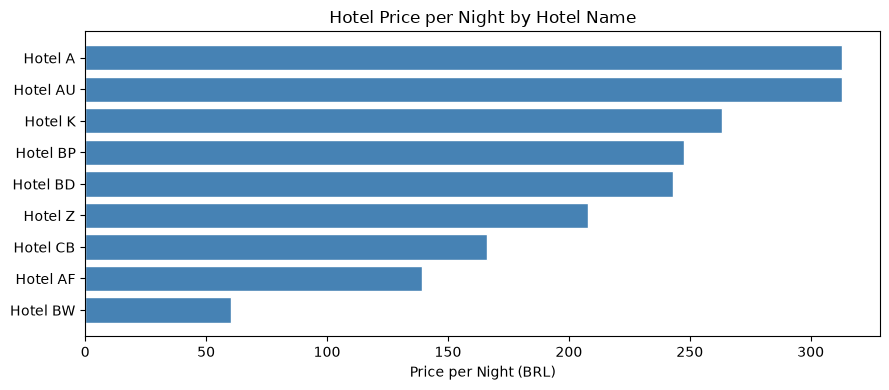

In [6]:
plt.figure(figsize=(9, 4))

plt.barh(hotel_catalog['name'], hotel_catalog['price_per_night'],
         color='steelblue', edgecolor='white')

plt.xlabel('Price per Night (BRL)')
plt.title('Hotel Price per Night by Hotel Name')
plt.tight_layout()
plt.show()

Hotel A and Hotel AU are the most expensive at around 313 BRL per night while Hotel BW is the cheapest at 60 BRL per night. There is a big price gap between the top and bottom hotels which gives the recommendation algorithm a good range to work with depending on the user budget.

## Step 6 — Save Hotel Catalog

In [7]:
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

hotel_catalog.to_csv(PROCESSED_DIR / "hotel_catalog.csv", index=False)

print("Saved hotel_catalog.csv to:", PROCESSED_DIR)
print("Rows saved:", len(hotel_catalog))
print()
print(hotel_catalog.to_string(index=False))

Saved hotel_catalog.csv to: c:\Voyage_Project\data\processed
Rows saved: 9

    name               place  price_per_night  total_bookings  avg_days_stayed
Hotel BW   Campo Grande (MS)            60.39            4333              2.5
Hotel AF      Sao Paulo (SP)           139.10            4828              2.5
Hotel CB Rio de Janeiro (RJ)           165.99            5029              2.5
 Hotel Z        Aracaju (SE)           208.04            4205              2.5
Hotel BD          Natal (RN)           242.88            4829              2.5
Hotel BP       Brasilia (DF)           247.62            4437              2.5
 Hotel K       Salvador (BH)           263.41            5094              2.5
Hotel AU         Recife (PE)           312.83            4467              2.5
 Hotel A  Florianopolis (SC)           313.02            3330              2.5
